# Wavelet Minimal Explanation Pipeline - Self-Contained Notebook

This notebook learns **minimal soft masks in wavelet subband space** instead of Fourier space.
Each subband (LL approximation + 3 detail subbands per level) receives one learned scalar
weight in [0,1]. The explanation is the IDWT reconstruction from the masked subbands.

## Cell 1 — Imports

In [ ]:
import os
import yaml

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as tvm
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, Dataset
from PIL import Image
from tqdm import tqdm
from pytorch_wavelets import DWTForward, DWTInverse

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


## Cell 2 - Load Config

Point `CONFIG_PATH` at your YAML config and set data inputs as before.

Wavelet-specific controls:
- `wavelet_levels`: number of DWT decomposition levels
- `wavelet_name`: wavelet family (e.g. `db4`, `haar`, `sym4`)
- `mask_threshold`: sigmoid threshold for binarising the soft mask


In [23]:
CONFIG_PATH = "/home/arin_weling/wavex/wavelet_explanation/configs/resnet18_imagenet_wavelet_minimal.yaml"
DATA_PATH = "../wavelet_explanation/data"

SINGLE_IMAGE_PATH = None

IMAGE_NAME_LIST = [
    "peacock.jpg",
]

RETRAIN_FROM_SCRATCH_PER_IMAGE = True
SAVE_INTERMEDIATE_EXPLANATIONS = False

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

# Wavelet soft-mask defaults.
config.setdefault("wavelet_levels", 5)
config.setdefault("wavelet_name", "db4")
config.setdefault("mask_temperature", 1.0)
config.setdefault("mask_threshold", 0.5)
config.setdefault("lambda_bins", 20.0)
config.setdefault("lambda_energy", 5.0)
config.setdefault("lambda_entropy", 0.0)

if not SAVE_INTERMEDIATE_EXPLANATIONS:
    config["viz_every"] = int(1e9)


def _safe_tag(value):
    base = os.path.splitext(os.path.basename(str(value)))[0]
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in base)
    cleaned = cleaned.strip("_")
    return cleaned or "run"


run_tag = None
if SINGLE_IMAGE_PATH:
    run_tag = _safe_tag(SINGLE_IMAGE_PATH)
elif isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0:
    first_name = str(IMAGE_NAME_LIST[0]).strip()
    run_tag = _safe_tag(first_name)
    if len(IMAGE_NAME_LIST) > 1:
        run_tag = f"{run_tag}_plus{len(IMAGE_NAME_LIST) - 1}"

CONFIG_NAME = os.path.splitext(os.path.basename(CONFIG_PATH))[0]
BASE_OUTPUT_DIR = f"my_exp_cam/outputs/{CONFIG_NAME}_wavelet_soft"
OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, run_tag) if run_tag else BASE_OUTPUT_DIR

import shutil
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
    print(f"Deleted old output directory: {OUTPUT_DIR}")

os.makedirs(OUTPUT_DIR, exist_ok=True)
config_save_path = f"{OUTPUT_DIR}/config.yaml"
shutil.copy(CONFIG_PATH, config_save_path)
print(f"Output directory: {OUTPUT_DIR}")
print(f"Config saved to: {config_save_path}")
print(f"Retrain from scratch per image: {RETRAIN_FROM_SCRATCH_PER_IMAGE}")
print(f"Save intermediate explanations: {SAVE_INTERMEDIATE_EXPLANATIONS}")
print(f"Wavelet: {config['wavelet_name']}, levels={config['wavelet_levels']}")
print(f"mask_temperature: {config['mask_temperature']}")
print(f"mask_threshold: {config['mask_threshold']}")
print(f"lambda_bins: {config['lambda_bins']}")
print(f"lambda_energy: {config['lambda_energy']}")
print(f"lambda_entropy: {config['lambda_entropy']}")


Deleted old output directory: my_exp_cam/outputs/resnet18_imagenet_wavelet_minimal_wavelet_soft/peacock
Output directory: my_exp_cam/outputs/resnet18_imagenet_wavelet_minimal_wavelet_soft/peacock
Config saved to: my_exp_cam/outputs/resnet18_imagenet_wavelet_minimal_wavelet_soft/peacock/config.yaml
Retrain from scratch per image: True
Save intermediate explanations: False
Wavelet: db8, levels=5
mask_temperature: 0.15
mask_threshold: 0.5
lambda_bins: 20000.0
lambda_energy: 9000.0
lambda_entropy: 50000.0


## Cell 3 - Wavelet Transform + Subband Masking

Uses `pytorch_wavelets` for autograd-compatible multi-level 2D DWT. The image is
decomposed into `1 + 3*L` subbands: one LL approximation and three detail subbands
(LH, HL, HH) per level. Each subband gets one learned scalar mask weight in [0, 1].
Coarser subbands come first in the mask vector.


In [24]:
WAVELET_LEVELS = int(config.get("wavelet_levels", 5))
WAVELET_NAME   = config.get("wavelet_name", "db4")
MASK_THRESHOLD = float(config.get("mask_threshold", 0.5))


class WaveletSubbandMasker(nn.Module):
    """DWT forward/inverse + spatial per-subband mask application (Option B)."""

    def __init__(self, n_levels=5, wavelet="db4"):
        super().__init__()
        self.n_levels = n_levels
        self._dwt  = DWTForward(J=n_levels, wave=wavelet, mode="periodization")
        self._idwt = DWTInverse(wave=wavelet, mode="periodization")

    def dwt(self, x):
        return self._dwt(x)

    def idwt(self, Yl, Yh):
        return self._idwt((Yl, Yh))

    def apply_masks(self, masks, Yl, Yh):
        """
        masks dict:
          'Yl': (B, 1, H_L, W_L)            — LL spatial mask
          'Yh': [(B, 3, H_l, W_l) for l]    — l=0 finest, l=L-1 coarsest
        Each mask broadcasts over C channels of the coefficients.
        """
        Yl_masked = Yl * masks["Yl"]
        Yh_masked = [Yh[l] * masks["Yh"][l].unsqueeze(1) for l in range(len(Yh))]
        return Yl_masked, Yh_masked

    def harden_masks(self, masks, threshold=None):
        threshold = MASK_THRESHOLD if threshold is None else float(threshold)
        return {
            "Yl": (masks["Yl"] >= threshold).float(),
            "Yh": [(m >= threshold).float() for m in masks["Yh"]],
        }

    def subband_labels(self):
        """One label per level (LL + L5..L1 coarse-to-fine)."""
        labels = ["LL"]
        for lev in range(self.n_levels, 0, -1):
            labels.append(f"L{lev}")
        return labels


def _masks_mean(masks):
    """Scalar mean of all spatial mask values across all subbands."""
    total = masks["Yl"].mean()
    for m in masks["Yh"]:
        total = total + m.mean()
    return total / (1 + len(masks["Yh"]))


def _detach_masks(masks):
    return {
        "Yl": masks["Yl"].detach(),
        "Yh": [m.detach() for m in masks["Yh"]],
    }


def _cpu_masks(masks):
    return {
        "Yl": masks["Yl"].detach().cpu(),
        "Yh": [m.detach().cpu() for m in masks["Yh"]],
    }


def _to_device_masks(masks, device):
    return {
        "Yl": masks["Yl"].to(device),
        "Yh": [m.to(device) for m in masks["Yh"]],
    }


wavelet = WaveletSubbandMasker(WAVELET_LEVELS, WAVELET_NAME).to(DEVICE)
print(f"Wavelet utilities ready: {WAVELET_NAME}, {WAVELET_LEVELS} levels (spatial masks)")


Wavelet utilities ready: db8, 5 levels (spatial masks)


## Cell 4 - Shared Soft Wavelet Subband Mask Autoencoder

Encoder-decoder (UNet) that outputs a soft subband mask of shape `(B, 1, n_subbands)`
— one scalar per DWT subband. The spatial feature map is globally average-pooled to
the `n_subbands` dimension before sigmoid activation.


In [25]:
def _conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm2d(out_ch, affine=True),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm2d(out_ch, affine=True),
        nn.ReLU(inplace=True),
    )


class _EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = _conv_block(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        features = self.conv(x)
        return self.pool(features), features   # (pooled, skip)


class _DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class WaveletMaskNet(nn.Module):
    """
    Multi-scale U-Net producing a *spatial* mask at every wavelet subband resolution.

    Output dict (all sigmoid, values in [0, 1]):
      'Yl':  (B, 1, H_L, W_L)             — LL approximation mask
      'Yh':  [(B, 3, H_l, W_l) for l]     — per-orientation detail masks
               l=0 finest (112x112 for 224 input, 5 levels)
               l=L-1 coarsest (7x7)

    Architecture (224x224 input, L=5):
      enc1: 224→112   enc2: 112→56   enc3: 56→28   enc4: 28→14   enc5: 14→7
      bottleneck: 7×7  →  head_7 → LL mask + Yh[4] mask
      dec5: 7→14       →  head_14 → Yh[3] mask
      dec4: 14→28      →  head_28 → Yh[2] mask
      dec3: 28→56      →  head_56 → Yh[1] mask
      dec2: 56→112     →  head_112 → Yh[0] mask
    """

    def __init__(self, in_channels=3, n_levels=5, temperature=1.0):
        super().__init__()
        self.n_levels    = n_levels
        self.temperature = float(temperature)

        # Encoder (5 blocks → 5 wavelet levels)
        self.enc1 = _EncoderBlock(in_channels, 32)
        self.enc2 = _EncoderBlock(32, 64)
        self.enc3 = _EncoderBlock(64, 128)
        self.enc4 = _EncoderBlock(128, 256)
        self.enc5 = _EncoderBlock(256, 256)
        self.bottleneck = _conv_block(256, 256)

        # Decoder (4 blocks — finest wavelet detail is at H/2)
        self.dec5 = _DecoderBlock(256, 256, 128)   # 7→14,  skip=enc5(14×14,256ch)
        self.dec4 = _DecoderBlock(128, 256, 128)   # 14→28, skip=enc4(28×28,256ch)
        self.dec3 = _DecoderBlock(128, 128,  64)   # 28→56, skip=enc3(56×56,128ch)
        self.dec2 = _DecoderBlock( 64,  64,  32)   # 56→112,skip=enc2(112×112,64ch)

        # Mask heads (1×1 conv at each wavelet scale)
        self.head_7   = nn.Conv2d(256, 4, 1)  # 4 = 1(LL) + 3(Yh[L-1])
        self.head_14  = nn.Conv2d(128, 3, 1)
        self.head_28  = nn.Conv2d(128, 3, 1)
        self.head_56  = nn.Conv2d( 64, 3, 1)
        self.head_112 = nn.Conv2d( 32, 3, 1)

        for h in [self.head_7, self.head_14, self.head_28, self.head_56, self.head_112]:
            nn.init.xavier_uniform_(h.weight, gain=0.1)
            nn.init.zeros_(h.bias)

    def forward(self, x):
        t = max(self.temperature, 1e-6)

        # ── Encoder ──────────────────────────────────────────────────────────
        p1, s1 = self.enc1(x)    # p1(B,32,112,112)  s1(B,32,224,224)
        p2, s2 = self.enc2(p1)   # p2(B,64,56,56)    s2(B,64,112,112)
        p3, s3 = self.enc3(p2)   # p3(B,128,28,28)   s3(B,128,56,56)
        p4, s4 = self.enc4(p3)   # p4(B,256,14,14)   s4(B,256,28,28)
        p5, s5 = self.enc5(p4)   # p5(B,256,7,7)     s5(B,256,14,14)
        b = self.bottleneck(p5)  # b(B,256,7,7)

        # ── Mask heads ───────────────────────────────────────────────────────
        # Coarsest: 7×7 → LL mask + Yh[L-1] mask
        lg7 = self.head_7(b)
        mask_Yl  = torch.sigmoid(lg7[:, :1] / t)   # (B,1,7,7)
        mask_yh4 = torch.sigmoid(lg7[:, 1:] / t)   # (B,3,7,7)  Yh[4]

        # 14×14 → Yh[3]
        d5 = self.dec5(b, s5)
        mask_yh3 = torch.sigmoid(self.head_14(d5) / t)   # (B,3,14,14)

        # 28×28 → Yh[2]
        d4 = self.dec4(d5, s4)
        mask_yh2 = torch.sigmoid(self.head_28(d4) / t)   # (B,3,28,28)

        # 56×56 → Yh[1]
        d3 = self.dec3(d4, s3)
        mask_yh1 = torch.sigmoid(self.head_56(d3) / t)   # (B,3,56,56)

        # 112×112 → Yh[0] finest
        d2 = self.dec2(d3, s2)
        mask_yh0 = torch.sigmoid(self.head_112(d2) / t)  # (B,3,112,112)

        # Yh ordering matches pytorch_wavelets: l=0 finest, l=L-1 coarsest
        return {
            "Yl": mask_Yl,
            "Yh": [mask_yh0, mask_yh1, mask_yh2, mask_yh3, mask_yh4],
        }


in_channels      = 1 if config.get("dataset") == "mnist" else 3
MASK_TEMPERATURE = float(config.get("mask_temperature", 1.0))
unet = WaveletMaskNet(
    in_channels=in_channels,
    n_levels=WAVELET_LEVELS,
    temperature=MASK_TEMPERATURE,
).to(DEVICE)
n_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f"Spatial wavelet mask net ready: {n_params:,} trainable parameters")


Spatial wavelet mask net ready: 5,033,392 trainable parameters


## Cell 5 — Frozen Classifier + Activation Hooks

The classifier is frozen (`requires_grad=False`) so gradients still flow *through* it from the loss back to the explanation network.

In [26]:
# ── Frozen Classifier ──────────────────────────────────────────────────────

_BACKBONE_REGISTRY = {
    "resnet18":          (tvm.resnet18,          tvm.ResNet18_Weights.DEFAULT),
    "mobilenet_v3_small":(tvm.mobilenet_v3_small, tvm.MobileNet_V3_Small_Weights.DEFAULT),
    "convnext_small":    (tvm.convnext_small,     tvm.ConvNeXt_Small_Weights.DEFAULT),
    "efficientnet_b0":   (tvm.efficientnet_b0,    tvm.EfficientNet_B0_Weights.DEFAULT),
    "vit_b_16":          (tvm.vit_b_16,           tvm.ViT_B_16_Weights.DEFAULT),
}

backbone_name = config.get("backbone", "resnet18")
pretrained = config.get("pretrained", True)

model_fn, weights = _BACKBONE_REGISTRY[backbone_name]
classifier = model_fn(weights=weights if pretrained else None).to(DEVICE)

for param in classifier.parameters():
    param.requires_grad = False
classifier.eval()

print(f"Frozen classifier: {backbone_name} (pretrained={pretrained})")


# ── Activation Hook Manager ───────────────────────────────────────────────

class ActivationHookManager:
    """Captures intermediate activations from Conv2d, Linear, ReLU layers."""

    def __init__(self, model):
        self._hooks = []
        self._activations = {}
        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear, nn.ReLU)):
                ltype = "linear" if isinstance(module, nn.Linear) else (
                    "conv" if isinstance(module, nn.Conv2d) else "relu")
                hook = module.register_forward_hook(self._make_hook(name, ltype))
                self._hooks.append(hook)

    def _make_hook(self, name, layer_type):
        def hook(module, inp, output):
            self._activations[name] = (output, layer_type)
        return hook

    def get_activations(self):
        return dict(self._activations)

    def clear(self):
        self._activations = {}

    def remove(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []

hook_manager = ActivationHookManager(classifier)
print(f"Activation hooks registered on {len(hook_manager._hooks)} layers.")

Frozen classifier: resnet18 (pretrained=True)
Activation hooks registered on 30 layers.


## Cell 6 - Losses + Wavelet Explanation Utilities

Same loss structure as the Fourier notebook, with wavelet-domain equivalents:
- **L_act** activation matching
- **L_CE** target class preservation
- **L_KL** output distribution alignment
- **L_rob** robustness under masked-out-subband noise
- **L_bins** soft subband activity (sparsity)
- **L_energy** normalized wavelet energy in kept subbands
- **L_entropy** mask entropy (encourages sharp 0/1 decisions)


In [27]:
_RESNET18_GROUP_WEIGHTS = [
    ("layer4", 8),
    ("layer3", 6),
    ("layer2", 4),
    ("layer1", 2),
]  # stem (conv1/bn1/relu) gets weight 1


def _resnet18_layer_weight(name):
    for prefix, w in _RESNET18_GROUP_WEIGHTS:
        if name.startswith(prefix):
            return w
    return 1


def activation_matching_loss(activations_x, activations_e):
    """Weighted activation matching; ResNet-18 group weights: stem=1, l1=2, l2=4, l3=6, l4=8."""
    common = sorted(set(activations_x) & set(activations_e))
    total = torch.tensor(0.0, device=DEVICE)
    for name in common:
        act_x, ltype = activations_x[name]
        act_e, _ = activations_e[name]
        if ltype == "linear":
            dist = (1.0 - F.cosine_similarity(act_x.detach(), act_e, dim=1)).mean()
        else:
            dist = F.mse_loss(act_e, act_x.detach())
        total = total + _resnet18_layer_weight(name) * dist
    return total

def cross_entropy_loss(logits_e, y):
    return F.cross_entropy(logits_e, y)


def kl_divergence_loss(logits_x, logits_e):
    top_idx = logits_x.detach().argmax(dim=1, keepdim=True)
    p_fake  = torch.zeros_like(logits_e).scatter_(1, top_idx, 1.0)
    log_q   = F.log_softmax(logits_e, dim=1)
    return F.kl_div(log_q, p_fake, reduction="batchmean")


def soft_bin_activity_loss(masks):
    """Mean mask activity across all spatial subband masks."""
    total = masks["Yl"].mean()
    for m in masks["Yh"]:
        total = total + m.mean()
    return total / (1 + len(masks["Yh"]))


def mask_entropy_loss(masks):
    """Mean m*(1-m) sharpness loss across all subband spatial masks."""
    def _sharp(m):
        return (m * (1.0 - m)).mean()
    total = _sharp(masks["Yl"])
    for m in masks["Yh"]:
        total = total + _sharp(m)
    return total / (1 + len(masks["Yh"]))


def explanation_wavelet_energy_loss(x, masks):
    """Penalize normalized energy in softly kept wavelet subbands."""
    Yl, Yh       = wavelet.dwt(x)
    Yl_m, Yh_m  = wavelet.apply_masks(masks, Yl, Yh)
    exp_energy   = Yl_m.pow(2).sum(dim=(1, 2, 3))
    total_energy = Yl.pow(2).sum(dim=(1, 2, 3))
    for l in range(len(Yh)):
        exp_energy   = exp_energy   + Yh_m[l].pow(2).sum(dim=(1, 2, 3, 4))
        total_energy = total_energy + Yh[l].pow(2).sum(dim=(1, 2, 3, 4))
    return (exp_energy / total_energy.clamp(min=1e-8)).mean()


def construct_explanation(x, masks):
    Yl, Yh      = wavelet.dwt(x)
    Yl_m, Yh_m = wavelet.apply_masks(masks, Yl, Yh)
    return wavelet.idwt(Yl_m, Yh_m)


def perturb_explanation(x, masks, noise_scale=0.1):
    Yl, Yh      = wavelet.dwt(x)
    Yl_m, Yh_m = wavelet.apply_masks(masks, Yl, Yh)

    std_Yl  = Yl.abs().std().detach().clamp(min=1e-6)
    Yl_pert = Yl_m + (1.0 - masks["Yl"]) * torch.randn_like(Yl) * noise_scale * std_Yl

    Yh_pert = []
    for l in range(len(Yh)):
        std_l = Yh[l].abs().std().detach().clamp(min=1e-6)
        m_l   = masks["Yh"][l].unsqueeze(1)   # (B,1,3,H,W) for C broadcast
        Yh_pert.append(Yh_m[l] + (1.0 - m_l) * torch.randn_like(Yh[l]) * noise_scale * std_l)

    return wavelet.idwt(Yl_pert, Yh_pert)


def to_numpy(t):
    t = t.detach().cpu().float()
    if t.ndim == 3 and t.shape[0] == 3:
        return np.clip(t.permute(1, 2, 0).numpy(), 0, 1)
    if t.ndim == 3 and t.shape[0] == 1:
        return np.clip(t.squeeze(0).numpy(), 0, 1)
    return np.clip(t.numpy(), 0, 1)


print("Wavelet losses and explanation utilities ready.")


Wavelet losses and explanation utilities ready.


## Cell 7 — Load Data

Same data-loading logic as the Fourier notebook (unchanged).

In [28]:
image_size = config.get("image_size", 224)
dataset_name = config.get("dataset", "imagenet")
batch_size = config.get("batch_size", 8)


def _build_transform():
    if dataset_name == "mnist":
        return T.Compose([T.Resize(image_size), T.ToTensor(), T.Normalize((0.1307,), (0.3081,))])
    resize_ops = [] if image_size == 64 else [T.Resize(int(image_size * 1.14)), T.CenterCrop(image_size)]
    return T.Compose([
        *resize_ops,
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


transform = _build_transform()


def _has_class_subdirs(root):
    if not os.path.isdir(root):
        return False
    return any(os.path.isdir(os.path.join(root, d)) for d in os.listdir(root))


def _resolve_imagefolder_root(root):
    """Support both standard roots and roots containing a train/ subfolder."""
    direct_root = root
    train_root = os.path.join(root, "train")
    if _has_class_subdirs(direct_root):
        return direct_root
    if _has_class_subdirs(train_root):
        return train_root
    return train_root


downloaded_path = globals().get("path", None)
DATA_ROOT = DATA_PATH
if isinstance(downloaded_path, str) and os.path.isdir(downloaded_path):
    DATA_ROOT = downloaded_path
    print(f"Using provided downloaded path as data root: {DATA_ROOT}")

use_standard_folder_loader = (
    isinstance(downloaded_path, str)
    and os.path.isdir(downloaded_path)
    and (_has_class_subdirs(downloaded_path) or _has_class_subdirs(os.path.join(downloaded_path, "train")))
)
if use_standard_folder_loader:
    print("Detected standard class-folder structure in provided path; using dataset loader.")

effective_single_image_mode = bool(config.get("single_image_mode", False))
if use_standard_folder_loader and effective_single_image_mode:
    print("Overriding config single_image_mode=True to process the full folder dataset.")
    effective_single_image_mode = False


class ImageNameListDataset(Dataset):
    """Loads images by filename from DATA_ROOT and assigns pseudo-labels via the frozen classifier."""

    def __init__(self, image_name_list, data_root, transform_fn, in_ch):
        if not isinstance(image_name_list, (list, tuple)):
            raise ValueError("IMAGE_NAME_LIST must be a list/tuple of image filenames.")

        self.transform_fn = transform_fn
        self.image_mode = "RGB" if in_ch == 3 else "L"
        self.image_names = [str(name).strip() for name in image_name_list if str(name).strip()]

        if len(self.image_names) == 0:
            raise ValueError("IMAGE_NAME_LIST is empty.")

        self.paths = []
        for name in self.image_names:
            p = os.path.join(data_root, name)
            if not os.path.isfile(p):
                raise FileNotFoundError(f"Image not found under data root: {p}")
            self.paths.append(p)

        self.image_stems = [os.path.splitext(os.path.basename(p))[0] for p in self.paths]

        # Build pseudo-labels once so train_step can keep using CE/KL/robustness targets.
        self.labels = []
        classifier.eval()
        with torch.no_grad():
            for p in self.paths:
                img = Image.open(p).convert(self.image_mode)
                x = self.transform_fn(img).unsqueeze(0).to(DEVICE)
                y = classifier(x).argmax(dim=1).item()
                self.labels.append(int(y))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert(self.image_mode)
        x = self.transform_fn(img)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


# -- Mode selection ------------------------------------------------------------
single_image_mode = False
dataloader = None
selected_image_tag = None


if isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not use_standard_folder_loader):
    # Image-name-list mode: each image is loaded from DATA_ROOT/image_name.
    dataset = ImageNameListDataset(IMAGE_NAME_LIST, DATA_ROOT, transform, in_channels)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    selected_image_tag = dataset.image_stems[0]
    print(
        f"Image-name-list mode: {len(dataset)} images from data root={DATA_ROOT} "
        f"| batch_size={batch_size}"
    )

elif SINGLE_IMAGE_PATH:
    # Single image mode.
    img = Image.open(SINGLE_IMAGE_PATH).convert("RGB" if in_channels == 3 else "L")
    fixed_x = transform(img).unsqueeze(0).to(DEVICE)
    fixed_class = config.get("fixed_class_label", None)
    fixed_class = None if fixed_class is None or str(fixed_class).lower() == "none" else fixed_class
    if fixed_class is not None:
        fixed_y = torch.tensor([int(fixed_class)], dtype=torch.long, device=DEVICE)
    else:
        with torch.no_grad():
            fixed_y = classifier(fixed_x).argmax(dim=1)
    single_image_mode = True
    selected_image_tag = os.path.splitext(os.path.basename(SINGLE_IMAGE_PATH))[0]
    print(f"Single image mode: {SINGLE_IMAGE_PATH} | target class: {fixed_y.item()}")

else:
    # Dataset mode from config.
    if dataset_name == "imagenet":
        # If a downloaded path is provided, prefer ImageFolder semantics for class-folder layout.
        if DATA_ROOT != DATA_PATH:
            imagefolder_root = _resolve_imagefolder_root(DATA_ROOT)
            dataset = torchvision.datasets.ImageFolder(root=imagefolder_root, transform=transform)
            print(
                "Dataset loader override: using ImageFolder for provided path "
                f"(root={imagefolder_root})."
            )
            dataset_name = "imagefolder"
        else:
            dataset = torchvision.datasets.ImageNet(root=DATA_ROOT, split="train", transform=transform)
    elif dataset_name == "imagefolder":
        imagefolder_root = _resolve_imagefolder_root(DATA_ROOT)
        dataset = torchvision.datasets.ImageFolder(root=imagefolder_root, transform=transform)
        print(f"ImageFolder root: {imagefolder_root}")
    elif dataset_name == "mnist":
        dataset = torchvision.datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
    elif dataset_name == "stl10":
        dataset = torchvision.datasets.STL10(root=DATA_ROOT, split="train", download=True, transform=transform)
    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

    # Optional class filter.
    filter_class = config.get("filter_class", None)
    if filter_class is not None:
        labels = np.array(dataset.labels if hasattr(dataset, "labels") else dataset.targets)
        dataset = Subset(dataset, np.where(labels == int(filter_class))[0].tolist())

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

    # Check for single-image-from-dataset mode.
    if effective_single_image_mode:
        idx = config.get("single_image_index", 0)
        img_tensor, _ = dataset[idx]
        fixed_x = img_tensor.unsqueeze(0).to(DEVICE)
        fc = config.get("fixed_class_label", None)
        fc = None if fc is None or str(fc).lower() == "none" else fc
        if fc is not None:
            fixed_y = torch.tensor([int(fc)], dtype=torch.long, device=DEVICE)
        else:
            with torch.no_grad():
                fixed_y = classifier(img_tensor.unsqueeze(0).to(DEVICE)).argmax(dim=1)
        single_image_mode = True
        selected_image_tag = f"dataset_idx_{idx}"
        print(f"Single image mode (from dataset index {idx}): target class {fixed_y.item()}")
    else:
        selected_image_tag = dataset_name
        print(f"Dataset: {dataset_name} | {len(dataloader.dataset)} examples | batch_size={batch_size}")


# Ensure output folder includes image tag when available.
def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


if selected_image_tag:
    desired_output_dir = os.path.join(BASE_OUTPUT_DIR, _safe_output_tag(selected_image_tag))
else:
    desired_output_dir = BASE_OUTPUT_DIR

if OUTPUT_DIR != desired_output_dir:
    OUTPUT_DIR = desired_output_dir
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# Keep a config copy inside the active save directory.
config_save_path = f"{OUTPUT_DIR}/config.yaml"
shutil.copy(CONFIG_PATH, config_save_path)
print(f"Active output directory: {OUTPUT_DIR}")

Image-name-list mode: 1 images from data root=../wavelet_explanation/data | batch_size=4
Active output directory: my_exp_cam/outputs/resnet18_imagenet_wavelet_minimal_wavelet_soft/peacock


## Cell 8 - Training Step

One gradient update:
1. UNet predicts soft wavelet subband mask `(B, 1, n_subbands)`
2. Build explanation `e = IDWT(m * DWT(x))`
3. Forward `x` and `e` through the frozen classifier
4. Compute combined loss and back-propagate into the UNet only


In [29]:
lambda_act     = config.get("lambda_act",     1.0)
lambda_CE      = config.get("lambda_CE",      4.0)
lambda_KL      = config.get("lambda_KL",      0.4)
lambda_rob     = config.get("lambda_rob",     6.0)
lambda_bins    = config.get("lambda_bins",   20.0)
lambda_energy  = config.get("lambda_energy",  5.0)
lambda_entropy = config.get("lambda_entropy", 0.0)

learning_rate = config.get("lr", 1e-4)


def _build_explainer_model():
    return WaveletMaskNet(
        in_channels=in_channels,
        n_levels=WAVELET_LEVELS,
        temperature=MASK_TEMPERATURE,
    ).to(DEVICE)


def reset_explainer_and_optimizer():
    global unet, optimizer
    unet      = _build_explainer_model()
    optimizer = torch.optim.Adam(unet.parameters(), lr=learning_rate)
    return unet, optimizer


optimizer         = torch.optim.Adam(unet.parameters(), lr=learning_rate)
fixed_class_label = config.get("fixed_class_label", None)


def train_step(x, y):
    unet.train()

    m_soft = unet(x)                        # dict of spatial masks
    e      = construct_explanation(x, m_soft)

    hook_manager.clear()
    logits_x      = classifier(x)
    activations_x = hook_manager.get_activations()

    hook_manager.clear()
    logits_e      = classifier(e)
    activations_e = hook_manager.get_activations()

    l_act = activation_matching_loss(activations_x, activations_e)

    if fixed_class_label is not None:
        y_target = torch.full((x.shape[0],), int(fixed_class_label), dtype=torch.long, device=x.device)
    else:
        y_target = logits_x.argmax(dim=1).detach()

    l_ce  = cross_entropy_loss(logits_e, y_target)
    l_kl  = kl_divergence_loss(logits_x, logits_e)

    e_pert      = perturb_explanation(x, m_soft)
    hook_manager.clear()
    logits_pert = classifier(e_pert)
    l_rob       = F.cross_entropy(logits_pert, y_target)

    l_bins    = soft_bin_activity_loss(m_soft)
    l_energy  = explanation_wavelet_energy_loss(x, m_soft)
    l_entropy = mask_entropy_loss(m_soft)

    probs_e     = torch.softmax(logits_e.detach(), dim=1)
    target_conf = probs_e.gather(1, y_target.unsqueeze(1)).mean()
    pred_conf   = probs_e.max(dim=1).values.mean()

    m_soft_det = _detach_masks(m_soft)
    m_hard     = wavelet.harden_masks(m_soft_det)

    l_exp = (
        lambda_act     * l_act
        + lambda_CE    * l_ce
        + lambda_KL    * l_kl
        + lambda_rob   * l_rob
        + lambda_bins  * l_bins
        + lambda_energy  * l_energy
        + lambda_entropy * l_entropy
    )

    optimizer.zero_grad()
    l_exp.backward()
    nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
    optimizer.step()

    return {
        "total":   l_exp.item(),
        "act":     (lambda_act    * l_act).item(),
        "ce":      (lambda_CE     * l_ce).item(),
        "kl":      (lambda_KL     * l_kl).item(),
        "rob":     (lambda_rob    * l_rob).item(),
        "bins":    (lambda_bins   * l_bins).item(),
        "energy":  (lambda_energy * l_energy).item(),
        "entropy": (lambda_entropy * l_entropy).item(),
        "mask_entropy":      float(l_entropy.detach().item()),
        "soft_mask_mean":    float(_masks_mean(m_soft).item()),
        "active_bins_ratio": float(_masks_mean(m_hard).item()),
        "target_confidence": float(target_conf.item()),
        "pred_confidence":   float(pred_conf.item()),
    }


print("train_step() defined for spatial wavelet subband minimal explanations.")


train_step() defined for spatial wavelet subband minimal explanations.


## Cell 9 — Training Loop

Runs epochs over the selected input mode. Supports optional per-image retraining when `IMAGE_NAME_LIST` and `RETRAIN_FROM_SCRATCH_PER_IMAGE` are enabled.

In [30]:
epochs = int(config.get("epochs", 50))
viz_every = int(config.get("viz_every", 1))
if viz_every < 1:
    raise ValueError(f"viz_every must be >= 1, got {viz_every}")

loss_history = []
latest_best_snapshot = None
per_image_loss_history = {}


def _denorm_for_snapshot(tensor):
    t = tensor.clone().cpu()
    if dataset_name in ("imagenet", "imagefolder", "stl10"):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        t = t * std + mean
    elif dataset_name == "mnist":
        t = t * 0.3081 + 0.1307
    return t.clamp(0, 1)


def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


def _capture_visual_snapshot(viz_sample_x_local):
    with torch.no_grad():
        unet.eval()
        m_soft_v   = unet(viz_sample_x_local)
        e_v        = construct_explanation(viz_sample_x_local, m_soft_v)
        logits_e_v = classifier(e_v)
        probs_e_v  = torch.softmax(logits_e_v, dim=1)
        top_conf_v, top_class_v = probs_e_v[0].max(dim=0)

    return {
        "epoch":      None,
        "loss_total": None,
        "m_soft":     _cpu_masks(m_soft_v),
        "m_hard":     _cpu_masks(wavelet.harden_masks(_detach_masks(m_soft_v))),
        "sample_x":  viz_sample_x_local.detach().cpu(),
        "x_denorm":  _denorm_for_snapshot(viz_sample_x_local),
        "e_denorm":  _denorm_for_snapshot(e_v),
        "top_class": int(top_class_v.item()),
        "top_conf":  float(top_conf_v.item()),
    }


def _run_training_for_fixed_sample(fixed_x_local, fixed_y_local, local_epochs):
    local_history = []
    window_best = None
    window_start_epoch = 1
    global latest_best_snapshot

    for epoch in range(1, local_epochs + 1):
        losses = train_step(fixed_x_local, fixed_y_local)
        local_history.append(losses)

        non_loss_keys = {"soft_mask_mean", "active_bins_ratio", "target_confidence", "pred_confidence"}
        loss_str = "  ".join(f"{k}={v:.4f}" for k, v in losses.items() if k not in non_loss_keys)
        print(
            f"Epoch {epoch:3d}/{local_epochs}  {loss_str}  "
            f"soft_mask_mean={losses['soft_mask_mean']:.4f}  "
            f"active_bins_ratio={losses['active_bins_ratio']:.4f}  "
            f"target_confidence={losses['target_confidence']:.4f}  "
            f"pred_confidence={losses['pred_confidence']:.4f}"
        )

        total_loss = float(losses.get("total", sum(v for k, v in losses.items() if k not in non_loss_keys)))
        if window_best is None or total_loss < window_best["loss_total"]:
            snap = _capture_visual_snapshot(fixed_x_local[:1])
            snap["epoch"] = epoch
            snap["loss_total"] = total_loss
            window_best = snap

        window_end = (epoch % viz_every == 0) or (epoch == local_epochs)
        if window_end and window_best is not None:
            latest_best_snapshot = window_best
            print(
                f"  -> Window best [{window_start_epoch}, {epoch}] at epoch {window_best['epoch']} "
                f"with total={window_best['loss_total']:.4f}"
            )
            window_start_epoch = epoch + 1
            window_best = None

    return local_history


image_list_mode = isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not single_image_mode)
retrain_per_image = bool(globals().get("RETRAIN_FROM_SCRATCH_PER_IMAGE", False)) and image_list_mode

if retrain_per_image:
    print("Image-list mode with retrain-from-scratch per image is ON.")

    if "dataset" not in globals():
        raise RuntimeError("Expected image-list dataset to be initialized in Cell 7.")

    for img_idx in range(len(dataset)):
        image_name = dataset.image_names[img_idx] if hasattr(dataset, "image_names") else f"img_{img_idx}"
        image_stem = dataset.image_stems[img_idx] if hasattr(dataset, "image_stems") else os.path.splitext(os.path.basename(str(image_name)))[0]
        x_img, y_img = dataset[img_idx]
        y_label = int(y_img.item()) if torch.is_tensor(y_img) else int(y_img)

        image_folder_tag = _safe_output_tag(f"{image_stem}_cls{y_label}")
        OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, image_folder_tag)
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        shutil.copy(CONFIG_PATH, f"{OUTPUT_DIR}/config.yaml")

        reset_explainer_and_optimizer()
        print(f"\n=== Training from scratch for image {img_idx + 1}/{len(dataset)}: {image_name} ===")

        fixed_x_img = x_img.unsqueeze(0).to(DEVICE)
        if fixed_class_label is not None:
            fixed_y_img = torch.tensor([int(fixed_class_label)], dtype=torch.long, device=DEVICE)
        else:
            fixed_y_img = torch.tensor([y_label], dtype=torch.long, device=DEVICE)

        local_loss_history = _run_training_for_fixed_sample(fixed_x_img, fixed_y_img, epochs)
        per_image_loss_history[image_folder_tag] = local_loss_history
        loss_history = local_loss_history

        ckpt_path = os.path.join(OUTPUT_DIR, "wavelet_masknet_checkpoint.pth")
        torch.save(
            {
                "encoder_decoder_state_dict": unet.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": config,
            },
            ckpt_path,
        )
        print(f"Checkpoint saved to {ckpt_path}")

    print("Training complete (per-image retrain mode).")

else:
    if single_image_mode:
        fixed_x_local = fixed_x
        fixed_y_local = fixed_y
        loss_history = _run_training_for_fixed_sample(fixed_x_local, fixed_y_local, epochs)
    else:
        # Dataset mode: average losses per epoch over batches.
        viz_sample_x, viz_sample_y = next(iter(dataloader))
        viz_sample_x = viz_sample_x[:1].to(DEVICE)
        if fixed_class_label is not None:
            viz_target = torch.tensor([int(fixed_class_label)], dtype=torch.long, device=DEVICE)
        else:
            with torch.no_grad():
                viz_target = classifier(viz_sample_x).argmax(dim=1)

        window_best = None
        window_start_epoch = 1

        for epoch in range(1, epochs + 1):
            accum = {}
            n = 0
            for x_batch, y_batch in tqdm(dataloader, desc=f"Epoch {epoch}", leave=False):
                x_batch = x_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                batch_losses = train_step(x_batch, y_batch)
                for k, v in batch_losses.items():
                    accum[k] = accum.get(k, 0.0) + v
                n += 1

            losses = {k: v / n for k, v in accum.items()}
            loss_history.append(losses)

            non_loss_keys = {"soft_mask_mean", "active_bins_ratio", "target_confidence", "pred_confidence"}
            loss_str = "  ".join(f"{k}={v:.4f}" for k, v in losses.items() if k not in non_loss_keys)
            print(
                f"Epoch {epoch:3d}/{epochs}  {loss_str}  "
                f"soft_mask_mean={losses['soft_mask_mean']:.4f}  "
                f"active_bins_ratio={losses['active_bins_ratio']:.4f}  "
                f"target_confidence={losses['target_confidence']:.4f}  "
                f"pred_confidence={losses['pred_confidence']:.4f}"
            )

            total_loss = float(losses.get("total", sum(v for k, v in losses.items() if k not in non_loss_keys)))
            if window_best is None or total_loss < window_best["loss_total"]:
                snap = _capture_visual_snapshot(viz_sample_x)
                snap["epoch"] = epoch
                snap["loss_total"] = total_loss
                window_best = snap

            window_end = (epoch % viz_every == 0) or (epoch == epochs)
            if window_end and window_best is not None:
                latest_best_snapshot = window_best
                print(
                    f"  -> Window best [{window_start_epoch}, {epoch}] at epoch {window_best['epoch']} "
                    f"with total={window_best['loss_total']:.4f}"
                )
                window_start_epoch = epoch + 1
                window_best = None

    ckpt_path = os.path.join(OUTPUT_DIR, "wavelet_masknet_checkpoint.pth")
    torch.save(
        {
            "encoder_decoder_state_dict": unet.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": config,
        },
        ckpt_path,
    )
    print(f"Checkpoint saved to {ckpt_path}")
    print("Training complete.")

Image-list mode with retrain-from-scratch per image is ON.

=== Training from scratch for image 1/1: peacock.jpg ===
Epoch   1/300  total=32109.6016  act=9266.5449  ce=64.3290  kl=0.0257  rob=0.0000  bins=9297.6846  energy=2061.9250  entropy=11419.0918  mask_entropy=0.2284  soft_mask_mean=0.4649  active_bins_ratio=0.4043  target_confidence=0.9936  pred_confidence=0.9936
Epoch   2/300  total=31203.5156  act=8556.2432  ce=1.5234  kl=0.0006  rob=0.0000  bins=9340.6533  energy=2398.2913  entropy=10906.8037  mask_entropy=0.2181  soft_mask_mean=0.4670  active_bins_ratio=0.4367  target_confidence=0.9998  pred_confidence=0.9998
Epoch   3/300  total=30336.0312  act=8136.9160  ce=0.6842  kl=0.0003  rob=0.0000  bins=9250.1143  energy=2122.8899  entropy=10825.4258  mask_entropy=0.2165  soft_mask_mean=0.4625  active_bins_ratio=0.4210  target_confidence=0.9999  pred_confidence=0.9999
Epoch   4/300  total=29042.7188  act=7409.0850  ce=0.2742  kl=0.0001  rob=0.0000  bins=9106.9512  energy=1699.7211  e

## Cell 10 — Loss Curves

Plot the training loss history to check convergence.

Saved loss curves to my_exp_cam/outputs/resnet18_imagenet_wavelet_minimal_wavelet_soft/peacock_cls84/loss_curves.png


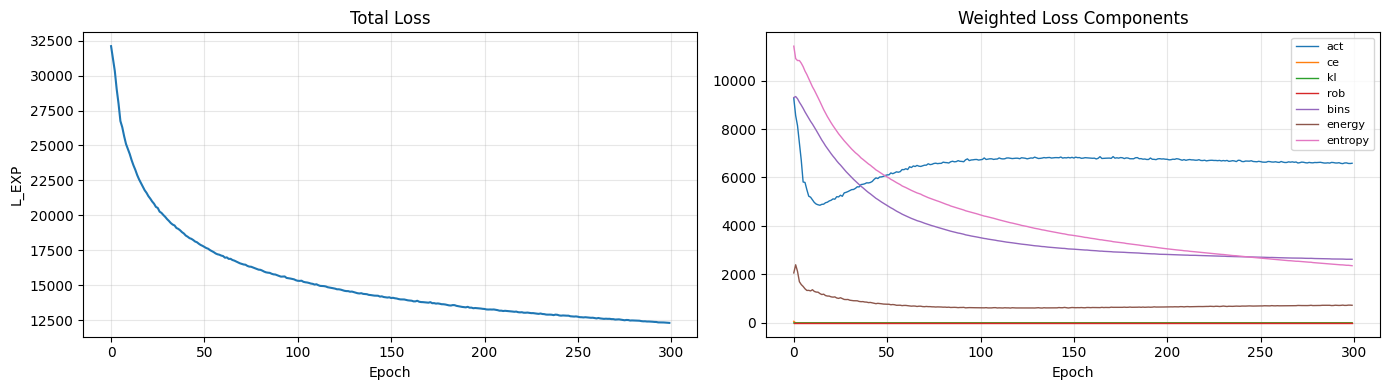

Saved active-bin ratio curve to my_exp_cam/outputs/resnet18_imagenet_wavelet_minimal_wavelet_soft/peacock_cls84/active_bins_ratio_curve.png


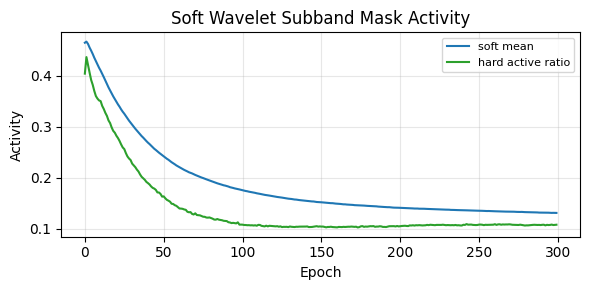

In [31]:
if len(loss_history) == 0:
    raise RuntimeError("loss_history is empty. Run training first.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot([h["total"] for h in loss_history], linewidth=1.5)
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("L_EXP")
axes[0].grid(True, alpha=0.3)

for key in ["act", "ce", "kl", "rob", "bins", "energy", "entropy"]:
    axes[1].plot([h.get(key, np.nan) for h in loss_history], label=key, linewidth=1)
axes[1].set_title("Weighted Loss Components")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curves.png", dpi=100, bbox_inches="tight")
print(f"Saved loss curves to {OUTPUT_DIR}/loss_curves.png")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot([h.get("soft_mask_mean", np.nan) for h in loss_history], linewidth=1.5, color="#1f77b4", label="soft mean")
ax.plot([h.get("active_bins_ratio", np.nan) for h in loss_history], linewidth=1.5, color="#2ca02c", label="hard active ratio")
ax.set_title("Soft Wavelet Subband Mask Activity")
ax.set_xlabel("Epoch")
ax.set_ylabel("Activity")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/active_bins_ratio_curve.png", dpi=100, bbox_inches="tight")
print(f"Saved active-bin ratio curve to {OUTPUT_DIR}/active_bins_ratio_curve.png")
plt.show()

## Cell 11 - Visualize Soft Wavelet Subband Explanation

Shows original, soft/hard masked reconstructions, and per-subband mask bar charts.

In [32]:
def denorm(tensor):
    t = tensor.clone().cpu()
    if dataset_name in ("imagenet", "imagefolder", "stl10"):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        t    = t * std + mean
    elif dataset_name == "mnist":
        t = t * 0.3081 + 0.1307
    return t.clamp(0, 1)


def to_numpy(t):
    t = t.detach().cpu().float()
    if t.ndim == 3 and t.shape[0] == 3:
        return np.clip(t.permute(1, 2, 0).numpy(), 0, 1)
    if t.ndim == 3 and t.shape[0] == 1:
        return np.clip(t.squeeze(0).numpy(), 0, 1)
    return np.clip(t.numpy(), 0, 1)


def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


def _run_visual_inference(sample_x):
    with torch.no_grad():
        unet.eval()
        m_soft    = unet(sample_x)
        e         = construct_explanation(sample_x, m_soft)
        logits_e  = classifier(e)
        probs_viz = torch.softmax(logits_e, dim=1)
        top_conf_tensor, top_class_tensor = probs_viz[0].max(dim=0)
    return {
        "m_soft":    m_soft,
        "m_hard":    wavelet.harden_masks(m_soft),
        "e":         e,
        "x_disp":    denorm(sample_x),
        "e_disp":    denorm(e),
        "top_class": int(top_class_tensor.item()),
        "top_conf":  float(top_conf_tensor.item()),
    }


def _level_mask_means(masks):
    """Per-level scalar means: [LL, L5(coarsest), L4, L3, L2, L1(finest)]."""
    vals = [masks["Yl"][0, 0].mean().item()]
    for m in reversed(masks["Yh"]):          # reversed: Yh[L-1] coarsest first
        vals.append(m[0].mean().item())
    return vals


def _save_wavelet_explanation_figure(result, save_path, title_suffix=""):
    labels  = wavelet.subband_labels()       # ["LL", "L5", "L4", "L3", "L2", "L1"]
    s_vals  = _level_mask_means(result["m_soft"])
    h_vals  = _level_mask_means(result["m_hard"])

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    fig.suptitle(f"Soft Wavelet Subband Explanation {title_suffix}".strip(),
                 fontsize=12, fontweight="bold")

    axes[0][0].imshow(to_numpy(result["x_disp"][0]))
    axes[0][0].set_title("Original")
    axes[0][0].axis("off")

    axes[0][1].bar(range(len(labels)), s_vals, color="steelblue")
    axes[0][1].set_xticks(range(len(labels)))
    axes[0][1].set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    axes[0][1].set_ylim(0, 1)
    axes[0][1].set_title("Soft Mask (per-level mean)")
    axes[0][1].grid(axis="y", alpha=0.3)

    axes[0][2].imshow(to_numpy(result["e_disp"][0]))
    axes[0][2].set_title(f"Soft Explanation (conf={result['top_conf']:.4f})")
    axes[0][2].axis("off")

    axes[1][0].bar(range(len(labels)), h_vals, color="tomato")
    axes[1][0].set_xticks(range(len(labels)))
    axes[1][0].set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    axes[1][0].set_ylim(0, 1)
    axes[1][0].set_title(f"Hard Mask >= {MASK_THRESHOLD:.2f}")
    axes[1][0].grid(axis="y", alpha=0.3)

    axes[1][1].axis("off")
    axes[1][1].text(0.02, 0.95,
                    f"Pred class: {result['top_class']}\nConf: {result['top_conf']:.4f}",
                    va="top", fontsize=11)
    axes[1][2].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.close()

image_list_mode   = isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not single_image_mode)
retrain_per_image = bool(globals().get("RETRAIN_FROM_SCRATCH_PER_IMAGE", False)) and image_list_mode

if image_list_mode and retrain_per_image and ("dataset" in globals()):
    print("Saving one final wavelet explanation per processed image...")
    saved_paths = []

    for img_idx in range(len(dataset)):
        image_name  = dataset.image_names[img_idx] if hasattr(dataset, "image_names") else f"img_{img_idx}"
        image_stem  = dataset.image_stems[img_idx] if hasattr(dataset, "image_stems") else os.path.splitext(os.path.basename(str(image_name)))[0]
        x_img, y_img = dataset[img_idx]
        y_label      = int(y_img.item()) if torch.is_tensor(y_img) else int(y_img)
        image_folder_tag = _safe_output_tag(f"{image_stem}_cls{y_label}")
        image_output_dir = os.path.join(BASE_OUTPUT_DIR, image_folder_tag)
        os.makedirs(image_output_dir, exist_ok=True)

        ckpt_path = os.path.join(image_output_dir, "wavelet_masknet_checkpoint.pth")
        if not os.path.isfile(ckpt_path):
            print(f"Skipping {image_name}: checkpoint not found at {ckpt_path}")
            continue

        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        unet.load_state_dict(ckpt["encoder_decoder_state_dict"], strict=True)
        unet.eval()

        sample_x  = x_img.unsqueeze(0).to(DEVICE)
        result    = _run_visual_inference(sample_x)
        save_path = f"{image_output_dir}/wavelet_explanation_final_cls{result['top_class']}_conf{result['top_conf']:.4f}.png"
        _save_wavelet_explanation_figure(result, save_path)
        saved_paths.append(save_path)
        print(f"Saved explanation to {save_path}")

    if len(saved_paths) == 0:
        print("No per-image final explanations were saved.")
    else:
        print(f"Saved {len(saved_paths)} per-image final explanations.")

else:
    if "latest_best_snapshot" in globals() and latest_best_snapshot is not None:
        result = {
            "m_soft":    latest_best_snapshot["m_soft"],
            "m_hard":    latest_best_snapshot["m_hard"],
            "x_disp":    latest_best_snapshot["x_denorm"],
            "e_disp":    latest_best_snapshot["e_denorm"],
            "top_class": latest_best_snapshot["top_class"],
            "top_conf":  latest_best_snapshot["top_conf"],
        }
    else:
        if single_image_mode:
            sample_x = fixed_x
        else:
            sample_x, _ = next(iter(dataloader))
            sample_x    = sample_x[:1].to(DEVICE)
        result = _run_visual_inference(sample_x)

    save_path = f"{OUTPUT_DIR}/wavelet_explanation_final_cls{result['top_class']}_conf{result['top_conf']:.4f}.png"
    _save_wavelet_explanation_figure(result, save_path)
    print(f"Saved explanation to {save_path}")

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(to_numpy(result["e_disp"][0]))
    ax.set_title("Final Explanation Preview")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


Saving one final wavelet explanation per processed image...
Saved explanation to my_exp_cam/outputs/resnet18_imagenet_wavelet_minimal_wavelet_soft/peacock_cls84/wavelet_explanation_final_cls84_conf1.0000.png
Saved 1 per-image final explanations.


## Cell 12 - Wavelet Subband Attribution Map

Shows:
- Soft and hard subband mask values (bar charts, coarsest to finest)
- Soft and hard masked reconstruction images
- Level-1 (finest) wavelet detail subbands: LH, HL, HH


Saved frequency-bin attribution to my_exp_cam/outputs/resnet18_imagenet_wavelet_minimal_wavelet_soft/peacock_cls84/wavelet_bin_attribution.png


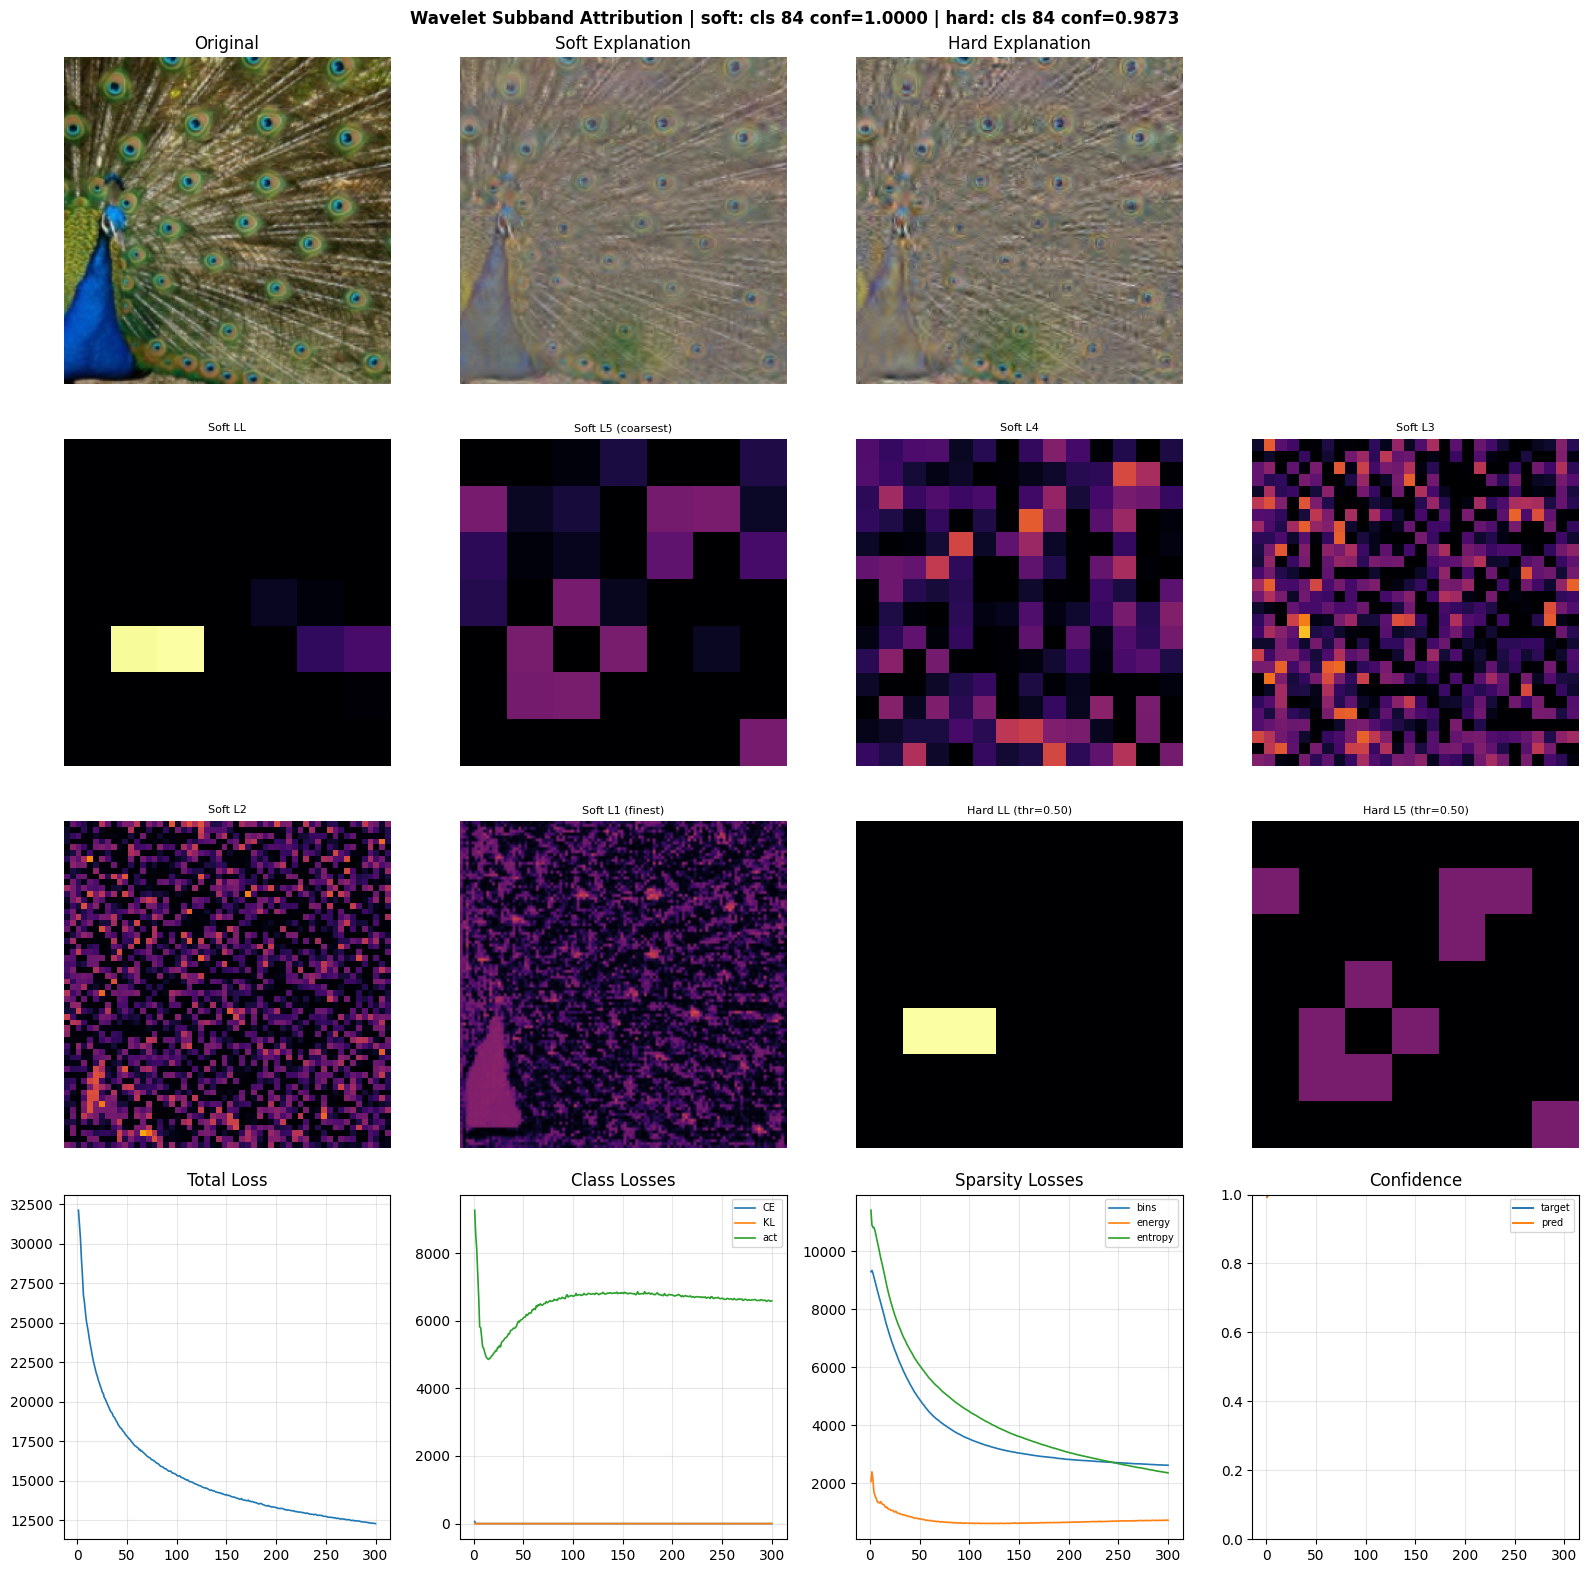

In [33]:
if "latest_best_snapshot" in globals() and latest_best_snapshot is not None:
    m_soft_viz   = _to_device_masks(latest_best_snapshot["m_soft"], DEVICE)
    sample_x_viz = latest_best_snapshot["sample_x"].to(DEVICE)
else:
    if single_image_mode:
        sample_x_viz = fixed_x[:1]
    else:
        sample_x_viz, _ = next(iter(dataloader))
        sample_x_viz    = sample_x_viz[:1].to(DEVICE)
    with torch.no_grad():
        m_soft_viz = unet(sample_x_viz)

with torch.no_grad():
    m_hard_viz = wavelet.harden_masks(m_soft_viz)

    e_soft_viz  = construct_explanation(sample_x_viz, m_soft_viz)
    probs_soft  = torch.softmax(classifier(e_soft_viz), dim=1)
    soft_conf, soft_class = probs_soft[0].max(dim=0)

    e_hard_viz  = construct_explanation(sample_x_viz, m_hard_viz)
    probs_hard  = torch.softmax(classifier(e_hard_viz), dim=1)
    hard_conf, hard_class = probs_hard[0].max(dim=0)

    x_disp_local = denorm(sample_x_viz)
    e_soft_disp  = denorm(e_soft_viz)
    e_hard_disp  = denorm(e_hard_viz)


def _mask_heatmap(m_tensor, ax, title):
    """Display a (B,1,H,W) or (B,3,H,W) spatial mask as a heatmap (mean across ch)."""
    img = m_tensor[0].mean(dim=0).detach().cpu().numpy()
    im  = ax.imshow(img, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(title, fontsize=8)
    ax.axis("off")
    return im


fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle(
    f"Wavelet Subband Attribution | "
    f"soft: cls {int(soft_class.item())} conf={float(soft_conf.item()):.4f} | "
    f"hard: cls {int(hard_class.item())} conf={float(hard_conf.item()):.4f}",
    fontsize=12, fontweight="bold",
)

# ── Row 0: images ────────────────────────────────────────────────────────────
axes[0][0].imshow(to_numpy(x_disp_local[0]))
axes[0][0].set_title("Original"); axes[0][0].axis("off")

axes[0][1].imshow(to_numpy(e_soft_disp[0]))
axes[0][1].set_title("Soft Explanation"); axes[0][1].axis("off")

axes[0][2].imshow(to_numpy(e_hard_disp[0]))
axes[0][2].set_title("Hard Explanation"); axes[0][2].axis("off")

axes[0][3].axis("off")

# ── Rows 1–2: spatial mask heatmaps ─────────────────────────────────────────
# Layout:  LL soft | L5 soft | L4 soft | L3 soft
#          L2 soft | L1 soft | LL hard | L5 hard
# Yh ordering: Yh[0]=L1 finest, Yh[4]=L5 coarsest

_mask_heatmap(m_soft_viz["Yl"], axes[1][0], "Soft LL")
_mask_heatmap(m_soft_viz["Yh"][4], axes[1][1], "Soft L5 (coarsest)")
_mask_heatmap(m_soft_viz["Yh"][3], axes[1][2], "Soft L4")
_mask_heatmap(m_soft_viz["Yh"][2], axes[1][3], "Soft L3")

_mask_heatmap(m_soft_viz["Yh"][1], axes[2][0], "Soft L2")
_mask_heatmap(m_soft_viz["Yh"][0], axes[2][1], "Soft L1 (finest)")
_mask_heatmap(m_hard_viz["Yl"],    axes[2][2], f"Hard LL (thr={MASK_THRESHOLD:.2f})")
_mask_heatmap(m_hard_viz["Yh"][4], axes[2][3], f"Hard L5 (thr={MASK_THRESHOLD:.2f})")

# ── Row 3: loss curves ────────────────────────────────────────────────────────
if len(loss_history) > 0:
    epochs_axis = np.arange(1, len(loss_history) + 1)

    axes[3][0].plot(epochs_axis, [h["total"] for h in loss_history], linewidth=1.2)
    axes[3][0].set_title("Total Loss"); axes[3][0].grid(alpha=0.3)

    axes[3][1].plot(epochs_axis, [h.get("ce",  np.nan) for h in loss_history], label="CE",  linewidth=1.2)
    axes[3][1].plot(epochs_axis, [h.get("kl",  np.nan) for h in loss_history], label="KL",  linewidth=1.2)
    axes[3][1].plot(epochs_axis, [h.get("act", np.nan) for h in loss_history], label="act", linewidth=1.2)
    axes[3][1].legend(fontsize=7); axes[3][1].set_title("Class Losses"); axes[3][1].grid(alpha=0.3)

    axes[3][2].plot(epochs_axis, [h.get("bins",    np.nan) for h in loss_history], label="bins",    linewidth=1.2)
    axes[3][2].plot(epochs_axis, [h.get("energy",  np.nan) for h in loss_history], label="energy",  linewidth=1.2)
    axes[3][2].plot(epochs_axis, [h.get("entropy", np.nan) for h in loss_history], label="entropy", linewidth=1.2)
    axes[3][2].legend(fontsize=7); axes[3][2].set_title("Sparsity Losses"); axes[3][2].grid(alpha=0.3)

    axes[3][3].plot(epochs_axis, [h.get("target_confidence", np.nan) for h in loss_history], label="target", linewidth=1.4)
    axes[3][3].plot(epochs_axis, [h.get("pred_confidence",   np.nan) for h in loss_history], label="pred",   linewidth=1.4)
    axes[3][3].set_ylim(0, 1); axes[3][3].legend(fontsize=7)
    axes[3][3].set_title("Confidence"); axes[3][3].grid(alpha=0.3)
else:
    for ax in axes[3]:
        ax.axis("off")
    axes[3][0].text(0.5, 0.5, "Run training first", ha="center", va="center", transform=axes[3][0].transAxes)

plt.tight_layout()
save_path = f"{OUTPUT_DIR}/wavelet_bin_attribution.png"
plt.savefig(save_path, dpi=120, bbox_inches="tight")
print(f"Saved frequency-bin attribution to {save_path}")
plt.show()



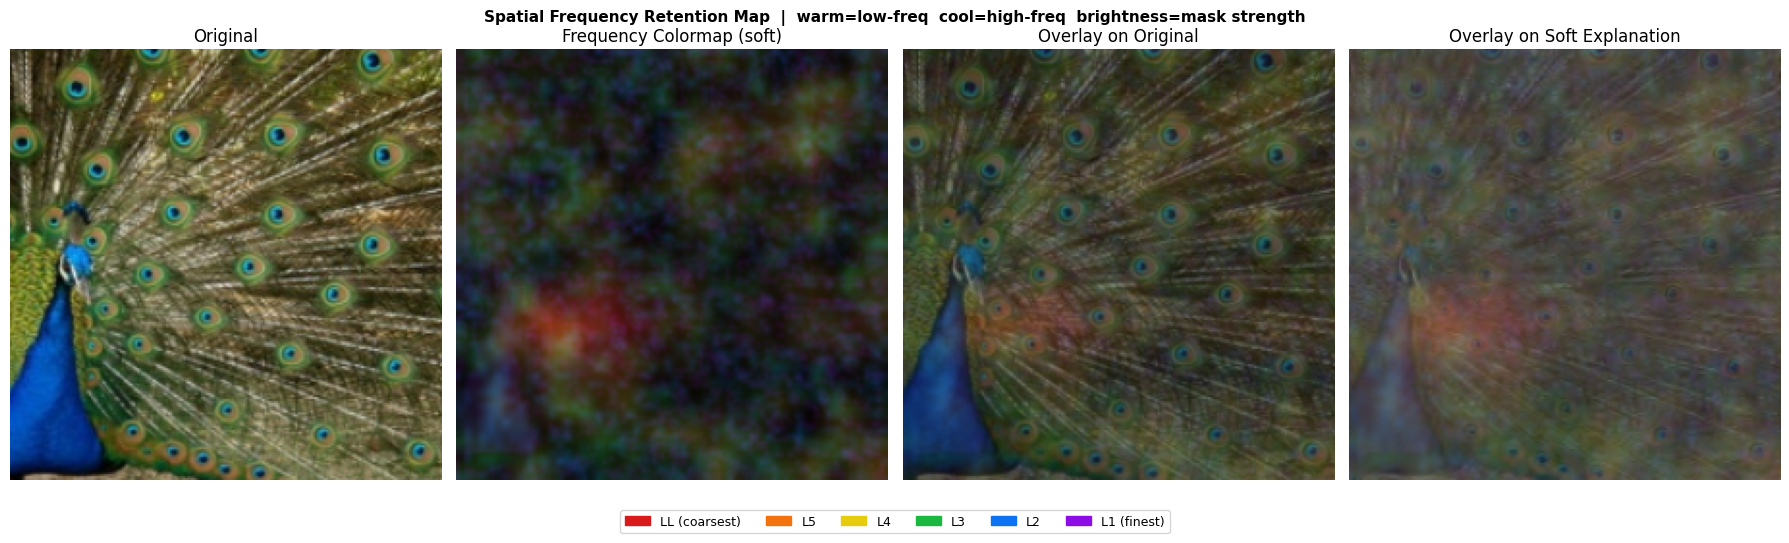

Saved: my_exp_cam/outputs/resnet18_imagenet_wavelet_minimal_wavelet_soft/peacock_cls84/freq_retention_map.png


In [34]:
# Levels ordered coarse→fine: LL, L5(Yh[4]), L4(Yh[3]), L3(Yh[2]), L2(Yh[1]), L1(Yh[0])
# Color = which frequency was retained; brightness = how strongly

H, W = sample_x_viz.shape[-2:]

LEVEL_COLORS = [
    [0.85, 0.10, 0.10],   # LL      — deep red
    [0.95, 0.45, 0.05],   # L5      — orange
    [0.90, 0.80, 0.05],   # L4      — yellow
    [0.10, 0.72, 0.25],   # L3      — green
    [0.05, 0.45, 0.95],   # L2      — blue
    [0.55, 0.05, 0.90],   # L1 (finest) — violet
]
LEVEL_NAMES = ['LL (coarsest)', 'L5', 'L4', 'L3', 'L2', 'L1 (finest)']

with torch.no_grad():
    def _upsample(t):
        if t.shape[1] > 1:
            t = t.mean(dim=1, keepdim=True)
        return F.interpolate(t.float(), size=(H, W), mode='bilinear',
                             align_corners=False)[0, 0].cpu()

    masks_up = [
        _upsample(m_soft_viz['Yl']),        # LL
        _upsample(m_soft_viz['Yh'][4]),     # L5 coarsest
        _upsample(m_soft_viz['Yh'][3]),     # L4
        _upsample(m_soft_viz['Yh'][2]),     # L3
        _upsample(m_soft_viz['Yh'][1]),     # L2
        _upsample(m_soft_viz['Yh'][0]),     # L1 finest
    ]

# Build weighted color map: sum(mask_l * color_l) / sum(mask_l)
freq_rgb   = torch.zeros(H, W, 3)
total_mask = torch.zeros(H, W)
for mask, color in zip(masks_up, LEVEL_COLORS):
    c = torch.tensor(color)
    freq_rgb   += mask.unsqueeze(-1) * c
    total_mask += mask

hue_map      = (freq_rgb / total_mask.clamp(min=1e-6).unsqueeze(-1)).clamp(0, 1).numpy()
strength_map = (total_mask / total_mask.max().clamp(min=1e-6)).numpy()
freq_map_vis = (hue_map * strength_map[..., np.newaxis]).clip(0, 1)

orig_np      = to_numpy(denorm(sample_x_viz)[0])
expl_np      = to_numpy(denorm(e_soft_viz)[0])
alpha        = 0.55
overlay_orig = np.clip(alpha * freq_map_vis + (1 - alpha) * orig_np, 0, 1)
overlay_expl = np.clip(alpha * freq_map_vis + (1 - alpha) * expl_np, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(
    'Spatial Frequency Retention Map  |  warm=low-freq  cool=high-freq  brightness=mask strength',
    fontsize=11, fontweight='bold'
)

axes[0].imshow(orig_np);        axes[0].set_title('Original');                    axes[0].axis('off')
axes[1].imshow(freq_map_vis);   axes[1].set_title('Frequency Colormap (soft)');   axes[1].axis('off')
axes[2].imshow(overlay_orig);   axes[2].set_title('Overlay on Original');          axes[2].axis('off')
axes[3].imshow(overlay_expl);   axes[3].set_title('Overlay on Soft Explanation'); axes[3].axis('off')

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=n) for c, n in zip(LEVEL_COLORS, LEVEL_NAMES)]
fig.legend(handles=patches, loc='lower center', ncol=len(patches),
           fontsize=9, framealpha=0.8, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
freq_map_path = f'{OUTPUT_DIR}/freq_retention_map.png'
plt.savefig(freq_map_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {freq_map_path}')


## Cell 13 - Evaluation Metrics (Per-Image + GradCAM + Averages)

Compares the wavelet subband method against GradCAM baseline.
Wavelet-specific metrics: per-level mask weight fractions (approx_fraction, level1..levelL).


In [35]:
# import json
# import math

# ins_del_steps = int(config.get("ins_del_steps", 25))
# metrics_curve_max_samples = int(config.get("metrics_curve_max_samples", 4))


# def _safe_output_tag(name):
#     cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
#     cleaned = cleaned.strip("_")
#     return cleaned or "run"


# def _normalize_mask(mask):
#     m = mask.detach().float()
#     flat = m.view(m.shape[0], -1)
#     m_min = flat.min(dim=1).values.view(-1, 1, 1, 1)
#     m_max = flat.max(dim=1).values.view(-1, 1, 1, 1)
#     return ((m - m_min) / (m_max - m_min + 1e-8)).clamp(0.0, 1.0)


# def _auc01(curve):
#     xs = torch.linspace(0.0, 1.0, steps=curve.numel(), device=curve.device, dtype=curve.dtype)
#     return float(torch.trapz(curve, xs).item())


# def _pixel_ins_del_auc(xi, score_map, class_idx, n_steps=25):
#     _, H, W = xi.shape
#     total = H * W
#     ranked = torch.argsort(score_map.reshape(-1), descending=True)

#     base = torch.zeros_like(xi)
#     ins_vals, del_vals = [], []

#     for step in range(n_steps + 1):
#         k = int(round((step / float(n_steps)) * total))
#         mask_flat = torch.zeros(total, device=xi.device, dtype=xi.dtype)
#         if k > 0:
#             mask_flat[ranked[:k]] = 1.0
#         mask = mask_flat.view(1, H, W)

#         x_ins = base + xi * mask
#         x_del = xi * (1.0 - mask)

#         with torch.no_grad():
#             p_ins = F.softmax(classifier(x_ins.unsqueeze(0)), dim=1)[0, class_idx]
#             p_del = F.softmax(classifier(x_del.unsqueeze(0)), dim=1)[0, class_idx]
#         ins_vals.append(p_ins)
#         del_vals.append(p_del)

#     ins_curve = torch.stack(ins_vals)
#     del_curve = torch.stack(del_vals)
#     return _auc01(ins_curve), _auc01(del_curve)


# def _compute_faithfulness_metrics(x, logits_x, pred_x, mask_soft):
#     mask_soft = mask_soft.clamp(0.0, 1.0)
#     if mask_soft.shape[1] != 1:
#         mask_soft = mask_soft.mean(dim=1, keepdim=True)

#     with torch.no_grad():
#         pred_in = classifier(x * mask_soft).argmax(dim=1)
#         logits_masked_out = classifier(x * (1.0 - mask_soft))

#     fid_in = float((pred_in == pred_x).float().mean().item())

#     fx_c = logits_x.gather(1, pred_x.unsqueeze(1)).squeeze(1)
#     fx_masked_out_c = logits_masked_out.gather(1, pred_x.unsqueeze(1)).squeeze(1)
#     ff_median = float((fx_c - fx_masked_out_c).median().item())

#     n_curve = min(x.shape[0], max(1, metrics_curve_max_samples))
#     ins_scores, del_scores = [], []
#     for i in range(n_curve):
#         ins_auc_i, del_auc_i = _pixel_ins_del_auc(
#             x[i],
#             mask_soft[i, 0],
#             int(pred_x[i].item()),
#             n_steps=ins_del_steps,
#         )
#         ins_scores.append(ins_auc_i)
#         del_scores.append(del_auc_i)

#     insertion_auc = float(np.mean(ins_scores))
#     deletion_auc = float(np.mean(del_scores))

#     return {
#         "fid_in": fid_in,
#         "ff_median": ff_median,
#         "insertion_auc": insertion_auc,
#         "deletion_auc": deletion_auc,
#     }


# def _compute_shared_metrics(x, logits_x, logits_e, mask_soft):
#     pred_x = logits_x.argmax(dim=1)
#     pred_e = logits_e.argmax(dim=1)
#     label_pres = float((pred_x == pred_e).float().mean().item())

#     prob_x = F.softmax(logits_x, dim=1)
#     prob_e = F.softmax(logits_e, dim=1)
#     conf_x = prob_x[torch.arange(len(pred_x), device=x.device), pred_x]
#     conf_e = prob_e[torch.arange(len(pred_x), device=x.device), pred_x]
#     conf_delta = float((conf_e - conf_x).mean().item())

#     if mask_soft.shape[1] != 1:
#         mask_soft = mask_soft.mean(dim=1, keepdim=True)
#     mask_soft = mask_soft.clamp(0.0, 1.0)

#     activity = float(mask_soft.mean().item())
#     sparsity = float(1.0 - activity)

#     faith = _compute_faithfulness_metrics(x, logits_x, pred_x, mask_soft)

#     out = {
#         "label_preservation": label_pres,
#         "confidence_delta": conf_delta,
#         "activity": activity,
#         "sparsity": sparsity,
#         "target_confidence_original": float(conf_x.mean().item()),
#         "target_confidence_explanation": float(conf_e.mean().item()),
#     }
#     out.update(faith)
#     return out


# def _wavelet_level_fractions(masks):
#     """Fraction of mean mask activity on LL approx and each detail level."""
#     L = wavelet.n_levels
#     approx_frac = float(masks["Yl"][0, 0].mean().item())
#     level_fracs = {}
#     # Yh[0]=L1 finest ... Yh[L-1]=L(L) coarsest; label lev=1..L maps to Yh[L-lev]
#     for lev in range(1, L + 1):
#         frac = float(masks["Yh"][L - lev][0].mean().item())
#         level_fracs[f"level{lev}_fraction"] = frac
#     return approx_frac, level_fracs


# def _find_last_conv_layer(model):
#     for module in reversed(list(model.modules())):
#         if isinstance(module, nn.Conv2d):
#             return module
#     return None


# GRADCAM_TARGET_LAYER = _find_last_conv_layer(classifier)
# if GRADCAM_TARGET_LAYER is None:
#     print("Warning: No Conv2d layer found in classifier; GradCAM metrics will be NaN.")
# else:
#     print(f"GradCAM target layer: {GRADCAM_TARGET_LAYER.__class__.__name__}")


# def _compute_gradcam_mask(x, target_idx):
#     if GRADCAM_TARGET_LAYER is None:
#         return None

#     acts, grads = [], []

#     def _fwd_hook(module, inp, output):
#         acts.append(output)

#     def _bwd_hook(module, grad_input, grad_output):
#         grads.append(grad_output[0])

#     h_fwd = GRADCAM_TARGET_LAYER.register_forward_hook(_fwd_hook)
#     h_bwd = GRADCAM_TARGET_LAYER.register_full_backward_hook(_bwd_hook)

#     try:
#         x_cam = x.detach().clone().requires_grad_(True)
#         classifier.zero_grad(set_to_none=True)
#         logits = classifier(x_cam)
#         score = logits.gather(1, target_idx.view(-1, 1)).sum()
#         score.backward()

#         if len(acts) == 0 or len(grads) == 0:
#             return None

#         a = acts[0]
#         g = grads[0]
#         weights = g.mean(dim=(2, 3), keepdim=True)
#         cam = (weights * a).sum(dim=1, keepdim=True)
#         cam = F.relu(cam)
#         cam = F.interpolate(cam, size=x_cam.shape[-2:], mode="bilinear", align_corners=False)
#         cam = _normalize_mask(cam).detach()

#         classifier.zero_grad(set_to_none=True)
#         return cam
#     finally:
#         h_fwd.remove()
#         h_bwd.remove()


# def _subband_mask_to_spatial(masks, img_hw):
#     """Upsample spatial subband masks to image resolution and average for pixel-level metrics."""
#     H, W = img_hw
#     target = (H, W)
#     dev = masks["Yl"].device
#     parts = [F.interpolate(masks["Yl"].float(), size=target, mode="nearest")]
#     for m in masks["Yh"]:
#         m_mean = m.mean(dim=1, keepdim=True).float()   # (B,1,H_l,W_l)
#         parts.append(F.interpolate(m_mean, size=target, mode="nearest"))
#     return torch.stack(parts, dim=0).mean(dim=0).clamp(0, 1)


# def _evaluate_methods_on_batch(eval_x):
#     unet.eval()
#     classifier.eval()
#     L = wavelet.n_levels

#     with torch.no_grad():
#         logits_x      = classifier(eval_x)
#         m_soft        = unet(eval_x)
#         e_method      = construct_explanation(eval_x, m_soft)
#         logits_method = classifier(e_method)

#     method_mask    = _normalize_mask(_subband_mask_to_spatial(_detach_masks(m_soft), eval_x.shape[-2:]))
#     method_metrics = _compute_shared_metrics(eval_x, logits_x, logits_method, method_mask)

#     m_hard = wavelet.harden_masks(m_soft.detach())
#     method_metrics["soft_mask_mean"]    = float(_masks_mean(_detach_masks(m_soft)).item())
#     method_metrics["active_bins_ratio"] = float(_masks_mean(m_hard).item())
#     approx_frac, level_fracs = _wavelet_level_fractions(_detach_masks(m_soft))
#     method_metrics["approx_fraction"]   = approx_frac
#     method_metrics.update(level_fracs)

#     pred_x   = logits_x.argmax(dim=1).detach()
#     cam_mask = _compute_gradcam_mask(eval_x, pred_x)

#     nan_keys = (["label_preservation", "confidence_delta", "activity", "sparsity",
#                  "target_confidence_original", "target_confidence_explanation",
#                  "fid_in", "ff_median", "insertion_auc", "deletion_auc",
#                  "soft_mask_mean", "active_bins_ratio", "approx_fraction"]
#                 + [f"level{lev}_fraction" for lev in range(1, L + 1)])

#     if cam_mask is None:
#         gradcam_metrics = {k: float("nan") for k in nan_keys}
#     else:
#         with torch.no_grad():
#             gradcam_expl   = eval_x * cam_mask
#             logits_gradcam = classifier(gradcam_expl)
#         gradcam_metrics = _compute_shared_metrics(eval_x, logits_x, logits_gradcam, cam_mask)
#         gradcam_metrics["soft_mask_mean"]    = float("nan")
#         gradcam_metrics["active_bins_ratio"] = float("nan")
#         gradcam_metrics["approx_fraction"]   = float("nan")
#         for lev in range(1, L + 1):
#             gradcam_metrics[f"level{lev}_fraction"] = float("nan")

#     return method_metrics, gradcam_metrics

# def _is_number(x):
#     return isinstance(x, (int, float, np.floating)) and math.isfinite(float(x))


# def _average_metric_dict(metric_dicts):
#     all_keys = sorted(set().union(*[d.keys() for d in metric_dicts])) if metric_dicts else []
#     out = {}
#     for key in all_keys:
#         vals = [float(d[key]) for d in metric_dicts if key in d and _is_number(d[key])]
#         if len(vals) > 0:
#             out[key] = float(np.mean(vals))
#     return out


# def _write_json(path, payload):
#     with open(path, "w") as f:
#         json.dump(payload, f, indent=2)


# _level_pref = {f"level{lev}_fraction": "context" for lev in range(1, wavelet.n_levels + 1)}
# METRIC_PREFERENCE = {
#     "label_preservation":            "higher",
#     "confidence_delta":              "higher",
#     "activity":                      "lower",
#     "sparsity":                      "higher",
#     "target_confidence_original":    "higher",
#     "target_confidence_explanation": "higher",
#     "fid_in":                        "higher",
#     "ff_median":                     "higher",
#     "insertion_auc":                 "higher",
#     "deletion_auc":                  "lower",
#     "soft_mask_mean":                "lower",
#     "active_bins_ratio":             "lower",
#     "approx_fraction":               "context",
#     **_level_pref,
# }


# def _metric_pref_suffix(metric_name):
#     better = METRIC_PREFERENCE.get(metric_name, "higher")
#     if better == "higher":
#         return "higher better"
#     if better == "lower":
#         return "lower better"
#     return "context"


# def _metric_label(metric_name):
#     return f"{metric_name}\n({_metric_pref_suffix(metric_name)})"


# def _plot_method_comparison_bar(method_metrics, gradcam_metrics, title, save_path):
#     keys = sorted(set(method_metrics.keys()) | set(gradcam_metrics.keys()))
#     keys = [k for k in keys if _is_number(method_metrics.get(k, float("nan"))) or _is_number(gradcam_metrics.get(k, float("nan")))]
#     if len(keys) == 0:
#         print(f"Skipping bar plot (no numeric metrics): {save_path}")
#         return

#     method_vals = [float(method_metrics.get(k, float("nan"))) for k in keys]
#     gradcam_vals = [float(gradcam_metrics.get(k, float("nan"))) for k in keys]

#     x = np.arange(len(keys))
#     width = 0.38

#     fig, ax = plt.subplots(figsize=(max(12, len(keys) * 0.8), 5))
#     ax.bar(x - width / 2, method_vals, width, label="Your Method", color="#1f77b4")
#     ax.bar(x + width / 2, gradcam_vals, width, label="GradCAM", color="#ff7f0e")
#     ax.set_title(title, fontsize=12, fontweight="bold")
#     ax.set_ylabel("Metric Value")
#     ax.set_xticks(x)
#     metric_labels = [_metric_label(k) for k in keys]
#     ax.set_xticklabels(metric_labels, rotation=45, ha="right", fontsize=9)
#     ax.grid(axis="y", alpha=0.3)
#     ax.legend()

#     plt.tight_layout()
#     plt.savefig(save_path, dpi=120, bbox_inches="tight")
#     plt.close()
#     print(f"Saved bar chart: {save_path}")


# results = []
# image_list_mode = isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not single_image_mode)
# retrain_per_image = bool(globals().get("RETRAIN_FROM_SCRATCH_PER_IMAGE", False)) and image_list_mode

# if image_list_mode:
#     print("Evaluating per image (Wavelet method vs GradCAM)...")

#     if "dataset" not in globals():
#         raise RuntimeError("Expected image-list dataset to be initialized in Cell 7.")

#     for img_idx in range(len(dataset)):
#         image_name = dataset.image_names[img_idx] if hasattr(dataset, "image_names") else f"img_{img_idx}"
#         image_stem = dataset.image_stems[img_idx] if hasattr(dataset, "image_stems") else os.path.splitext(os.path.basename(str(image_name)))[0]
#         x_img, y_img = dataset[img_idx]
#         y_label = int(y_img.item()) if torch.is_tensor(y_img) else int(y_img)
#         image_folder_tag = _safe_output_tag(f"{image_stem}_cls{y_label}")
#         image_output_dir = os.path.join(BASE_OUTPUT_DIR, image_folder_tag)
#         os.makedirs(image_output_dir, exist_ok=True)

#         if retrain_per_image:
#             ckpt_path = os.path.join(image_output_dir, "wavelet_masknet_checkpoint.pth")
#             if not os.path.isfile(ckpt_path):
#                 print(f"Warning: checkpoint missing for {image_name}: {ckpt_path}")
#                 continue
#             ckpt = torch.load(ckpt_path, map_location=DEVICE)
#             unet.load_state_dict(ckpt["encoder_decoder_state_dict"], strict=True)

#         eval_x = x_img.unsqueeze(0).to(DEVICE)
#         method_metrics, gradcam_metrics = _evaluate_methods_on_batch(eval_x)

#         per_image_metrics_path = os.path.join(image_output_dir, "metrics_method_vs_gradcam.json")
#         record = {
#             "image_index": int(img_idx),
#             "image_name": str(image_name),
#             "output_dir": image_output_dir,
#             "method": method_metrics,
#             "gradcam": gradcam_metrics,
#             "metrics_json_path": per_image_metrics_path,
#         }
#         results.append(record)

#         _write_json(per_image_metrics_path, record)
#         print(f"Saved per-image metrics: {per_image_metrics_path}")

#         per_image_bar_path = os.path.join(image_output_dir, "metrics_method_vs_gradcam_bar.png")
#         _plot_method_comparison_bar(
#             method_metrics,
#             gradcam_metrics,
#             title=f"Method vs GradCAM ({image_stem})",
#             save_path=per_image_bar_path,
#         )

#     if len(results) == 0:
#         raise RuntimeError("No per-image metrics were generated.")

#     method_avg = _average_metric_dict([r["method"] for r in results])
#     gradcam_avg = _average_metric_dict([r["gradcam"] for r in results])

#     summary_path = os.path.join(BASE_OUTPUT_DIR, "metrics_method_vs_gradcam_summary.json")
#     summary = {
#         "num_images": len(results),
#         "method_average": method_avg,
#         "gradcam_average": gradcam_avg,
#         "per_image_results": results,
#         "summary_json_path": summary_path,
#     }

#     _write_json(summary_path, summary)
#     print(f"Saved average comparison summary: {summary_path}")

#     avg_bar_path = os.path.join(BASE_OUTPUT_DIR, "metrics_method_vs_gradcam_average_bar.png")
#     _plot_method_comparison_bar(
#         method_avg,
#         gradcam_avg,
#         title="Average Metrics: Wavelet Subband Method vs GradCAM",
#         save_path=avg_bar_path,
#     )

#     print("\n" + "=" * 60)
#     print("AVERAGE METRICS ACROSS IMAGES")
#     print("=" * 60)
#     print("\nYour Method:")
#     for k, v in method_avg.items():
#         print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")
#     print("\nGradCAM:")
#     for k, v in gradcam_avg.items():
#         print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")

# else:
#     if single_image_mode:
#         eval_x = fixed_x
#     else:
#         eval_x, _ = next(iter(dataloader))
#         eval_x = eval_x.to(DEVICE)

#     method_metrics, gradcam_metrics = _evaluate_methods_on_batch(eval_x)
#     payload = {
#         "num_images": int(eval_x.shape[0]),
#         "method": method_metrics,
#         "gradcam": gradcam_metrics,
#     }

#     fallback_json_path = os.path.join(OUTPUT_DIR, "metrics_method_vs_gradcam.json")
#     _write_json(fallback_json_path, payload)
#     print(f"Saved metrics comparison: {fallback_json_path}")

#     fallback_bar_path = os.path.join(OUTPUT_DIR, "metrics_method_vs_gradcam_bar.png")
#     _plot_method_comparison_bar(
#         method_metrics,
#         gradcam_metrics,
#         title="Method vs GradCAM (Current Batch)",
#         save_path=fallback_bar_path,
#     )

#     print("\n" + "=" * 50)
#     print("EVALUATION METRICS (CURRENT BATCH)")
#     print("=" * 50)
#     print("\nYour Method:")
#     for k, v in method_metrics.items():
#         if _is_number(v):
#             print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")
#     print("\nGradCAM:")
#     for k, v in gradcam_metrics.items():
#         if _is_number(v):
#             print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")

## Cell 14 — Save / Load Checkpoint

Save the trained wavelet subband mask autoencoder for later reuse.

In [36]:
# CHECKPOINT_PATH = "wavelet_masknet_checkpoint.pth"

# # Save
# torch.save({
#     "encoder_decoder_state_dict": unet.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "config": config,
# }, CHECKPOINT_PATH)
# print(f"Checkpoint saved to {CHECKPOINT_PATH}")

# # To load later:
# # ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
# # unet.load_state_dict(ckpt["encoder_decoder_state_dict"])
# # optimizer.load_state_dict(ckpt["optimizer_state_dict"])